In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)

# Fix common dataset issues
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # or median
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Define features & target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing pipeline
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])





(7043, 21)


In [23]:


df['AvgMonthlyCharge'] = df['MonthlyCharges'] / (df['tenure'].clip(lower=1))
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['<1yr', '1-2yr', '2-4yr', '>4yr'])
df['HasTechSupport'] = df['TechSupport'].apply(lambda x: 1 if x in ['Yes', 'No internet service'] else 0)
df['HasOnlineSecurity'] = df['OnlineSecurity'].apply(lambda x: 1 if x in ['Yes', 'No internet service'] else 0)



In [24]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load & clean data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Feature dtypes
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include=['object', 'string']).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Pipeline with SMOTE
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Split & fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipe.fit(X_train, y_train)

# Evaluate
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [25]:
from xgboost import XGBClassifier

# Define the XGBoost Pipeline
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# Fit the model
xgb_pipe.fit(X_train, y_train)

# Update results dictionary
results['XGBoost'] = xgb_pipe

# Evaluate and update pred_probas
pred_probas['XGBoost'], _ = evaluate_model(xgb_pipe, X_test, y_test, 'XGBoost')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.817


In [26]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, classification_report
import matplotlib.pyplot as plt

def evaluate_model(model, X, y, name):
    y_pred_proba = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)

    auc = roc_auc_score(y, y_pred_proba)
    print(f"\n=== {name} ===")
    print(classification_report(y, y_pred))
    print(f"ROC-AUC: {auc:.3f}")

    precision, recall, thresholds = precision_recall_curve(y, y_pred_proba)
    return y_pred_proba, auc


results = {"LogisticRegression": pipe}

pred_probas = {}
for name, model in results.items():
    pred_probas[name], _ = evaluate_model(model, X_test, y_test, name)


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.840


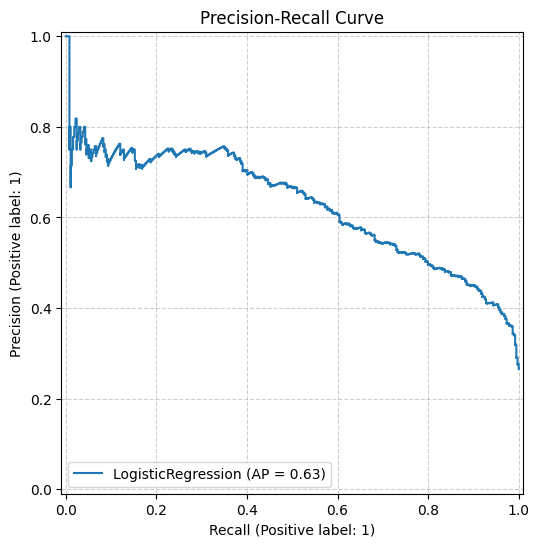

In [27]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, proba in pred_probas.items():
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=plt.gca())

plt.title('Precision-Recall Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

def objective(trial):
    # Define hyperparameter search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    # Re-create pipeline with suggested params
    xgb_tuned_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(**param))
    ])

    # Cross-validation for robust performance estimation
    score = cross_val_score(xgb_tuned_pipe, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

# Run Optuna Study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"Best F1-score: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

# Update results with the best model
best_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(**study.best_params))
])
best_xgb.fit(X_train, y_train)
results['XGBoost_Tuned'] = best_xgb
pred_probas['XGBoost_Tuned'], _ = evaluate_model(best_xgb, X_test, y_test, 'XGBoost_Tuned')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.4 MB/s eta 0:00:00


[I 2026-05-01 09:51:23,089] A new study created in memory with name: no-name-84c86b49-d3b8-4f02-9bdd-e6f85f58df07
[I 2026-05-01 09:51:52,552] Trial 0 finished with value: 0.5769013471347305 and parameters: {'n_estimators': 774, 'max_depth': 10, 'learning_rate': 0.027576714689383316, 'subsample': 0.5325975900032632, 'colsample_bytree': 0.7166784005366946}. Best is trial 0 with value: 0.5769013471347305.
[I 2026-05-01 09:52:04,740] Trial 1 finished with value: 0.5607895005475579 and parameters: {'n_estimators': 572, 'max_depth': 10, 'learning_rate': 0.14485018836095173, 'subsample': 0.6400229959596893, 'colsample_bytree': 0.5613739342110373}. Best is trial 0 with value: 0.5769013471347305.
[I 2026-05-01 09:52:08,656] Trial 2 finished with value: 0.5766014318662056 and parameters: {'n_estimators': 648, 'max_depth': 3, 'learning_rate': 0.24412061779424274, 'subsample': 0.876244687601627, 'colsample_bytree': 0.8515506460564288}. Best is trial 0 with value: 0.5769013471347305.
[I 2026-05-01 

Best F1-score: 0.6124
Best Params: {'n_estimators': 183, 'max_depth': 5, 'learning_rate': 0.0921286804027987, 'subsample': 0.965502373571735, 'colsample_bytree': 0.5048328341537764}

=== XGBoost_Tuned ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.832


In [28]:
print(f"Shape of pred_probas['LogisticRegression']: {pred_probas['LogisticRegression'].shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of pred_probas['LogisticRegression']: (1409,)
Shape of y_test: (1409,)


Explaining model: XGBoost_Tuned


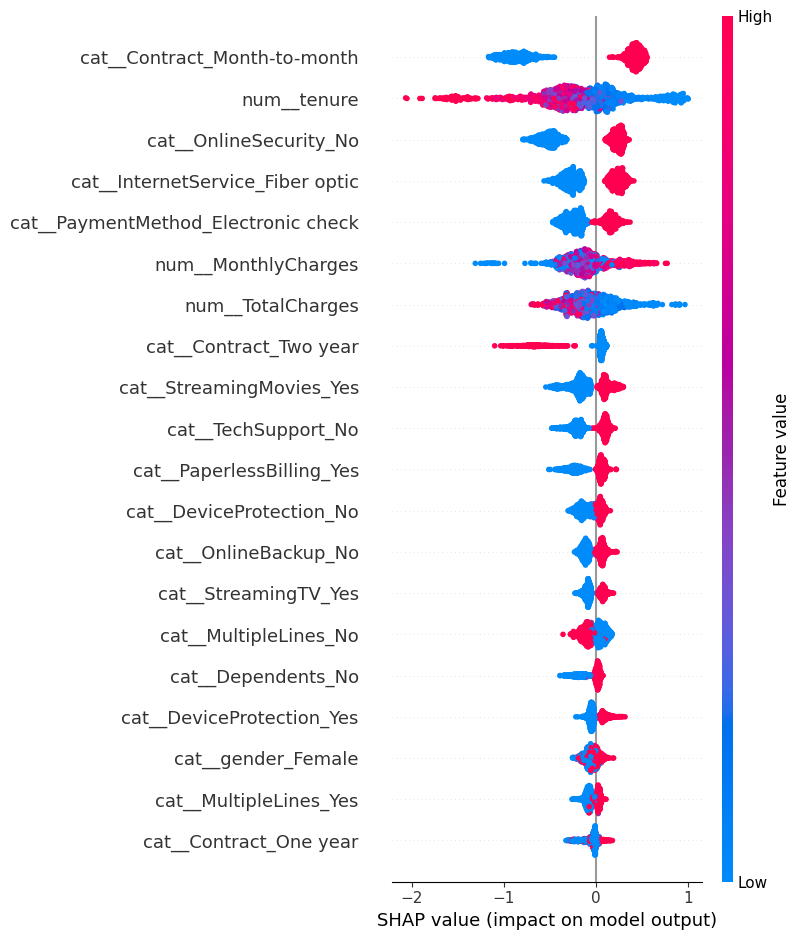

In [32]:
import shap

# Ensure we are using the model we just trained in the Optuna cell
model_key = 'XGBoost_Tuned'

if model_key not in results:
    print(f"Warning: {model_key} not found in results. Available keys: {list(results.keys())}")
    # Fallback to the 'best_xgb' variable directly if the dictionary key is missing
    xgb_pipe = best_xgb
else:
    xgb_pipe = results[model_key]

print(f"Explaining model: {model_key}")

xgb_model = xgb_pipe.named_steps['classifier']
preprocessor = xgb_pipe.named_steps['preprocessor']

# Transform the test data for explanation
X_test_proc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_proc)

# Plot Summary
shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names)

# Individual Force Plot (First instance)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_proc[0], feature_names=feature_names)